# Aspect Extraction from Airbnb Reviews using Gemma3 and Ollama

This notebook extracts main aspects (topics) from Airbnb reviews using the Gemma3 model via Ollama API.

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import requests
import json
import time
from tqdm import tqdm
import re
import warnings
warnings.filterwarnings('ignore')

# Set Ollama API endpoint
OLLAMA_API_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma3"

print(f"Ollama API endpoint: {OLLAMA_API_URL}")
print(f"Model: {MODEL_NAME}")

Ollama API endpoint: http://localhost:11434/api/generate
Model: gemma3


## 2. Check Ollama Connection

In [ ]:
# Test Ollama connection
def test_ollama_connection():
    try:
        # Test with a simple prompt
        payload = {
            "model": MODEL_NAME,
            "prompt": "Say hello",
            "stream": False
        }
        response = requests.post(OLLAMA_API_URL, json=payload, timeout=10)
        if response.status_code == 200:
            print("✓ Ollama connection successful!")
            result = response.json()
            print(f"Response: {result.get('response', '')[:100]}")
            return True
        else:
            print(f"✗ Ollama connection failed: Status {response.status_code}")
            return False
    except Exception as e:
        print(f"✗ Error connecting to Ollama: {str(e)}")
        print("Make sure Ollama is running: ollama serve")
        return False

# Test connection
test_ollama_connection()

✗ Error connecting to Ollama: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=10)
Make sure Ollama is running: ollama serve


False

## 3. Load Reviews Data

In [6]:
# Load the same reviews data
reviews_df = pd.read_csv('./data/reviews_select.csv', nrows=1000)

# Clean the data
reviews_df = reviews_df.dropna(subset=['comments'])
reviews_df['comments'] = reviews_df['comments'].astype(str)
reviews_df = reviews_df[reviews_df['comments'].str.strip() != '']
reviews_df = reviews_df.drop_duplicates(subset=['comments'])

print(f"Dataset shape: {reviews_df.shape}")
print(f"\nSample reviews:")
print(reviews_df['comments'].head(3).values)

Dataset shape: (1000, 10)

Sample reviews:
['Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso.'
 'Très bon emplacement pour cet appartement typique au cœur d une belle vie de quartier  tout en se préservant du calme. Hyper central pour visiter la capitale'
 'What a wonderful gem.  Great location, it was spotless and the studio was recently renovated. Even a new sofa bed.  We thoroughly enjoyed our stay and highly recommend.']


## 4. Define Aspect Extraction Function

In [ ]:
def extract_aspects(text, max_retries=3):
    """
    Extract main aspects from a review using Gemma3 via Ollama
    
    Args:
        text: The review text
        max_retries: Number of retries if the request fails
        
    Returns:
        List of aspects as strings
    """
    # Truncate text to reasonable length
    text = text[:1000]
    
    prompt = f"""Extract the main aspects (topics/themes) mentioned in this Airbnb review. 
Return only a comma-separated list of 3-10 key aspects. Be concise and specific.
Examples of aspects: cleanliness, location, communication, amenities, noise, comfort, value, host responsiveness, wifi, kitchen, bed quality, etc.

Review: "{text}"

Main aspects:"""
    
    for attempt in range(max_retries):
        try:
            payload = {
                "model": MODEL_NAME,
                "prompt": prompt,
                "stream": False,
                "temperature": 0.1,
                "top_p": 0.9
            }
            
            response = requests.post(OLLAMA_API_URL, json=payload, timeout=30)
            
            if response.status_code == 200:
                result = response.json()
                aspects_text = result.get('response', '').strip()
                # Parse the response into a list
                aspects = [asp.strip() for asp in aspects_text.split(',') if asp.strip()]
                return aspects
            else:
                if attempt < max_retries - 1:
                    time.sleep(2)
                    continue
                else:
                    return []
                    
        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
            else:
                return []
        except Exception as e:
            print(f"Error: {str(e)}")
            return []
    
    return []

# Test the function with a sample review
print("Testing aspect extraction...")
sample_review = reviews_df['comments'].iloc[0]
print(f"Sample review: {sample_review[:200]}...")
aspects = extract_aspects(sample_review)
print(f"Extracted aspects: {aspects}")

Testing aspect extraction...
Sample review: Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso....
Extracted aspects: ['Comfort', 'location', 'quietness']


pzerf: n=1000, t=01:20:05 mean=5s/item


In [8]:
# Extract aspects from all reviews
print("Extracting aspects from all reviews...")
print("This may take a while depending on the number of reviews...\n")

all_aspects = []
reviews_list = reviews_df['comments'].tolist()

for i, review in enumerate(tqdm(reviews_list, desc="Extracting aspects")):
    aspects = extract_aspects(review)
    all_aspects.append(aspects)
    
    # Add a small delay to avoid overwhelming the API
    if (i + 1) % 5 == 0:
        time.sleep(1)

# Add aspects to dataframe
reviews_df['aspects'] = all_aspects
reviews_df['aspects_count'] = reviews_df['aspects'].apply(len)

print(f"\nAspect extraction completed!")
print(f"\nSample results:")
print(reviews_df[['comments', 'aspects']].head(10))

Extracting aspects from all reviews...
This may take a while depending on the number of reviews...



Extracting aspects: 100%|██████████| 1000/1000 [1:20:50<00:00,  4.85s/it]


Aspect extraction completed!

Sample results:
                                            comments  \
0  Alloggio confortevole e pratico, dotato di tut...   
1  Très bon emplacement pour cet appartement typi...   
2  What a wonderful gem.  Great location, it was ...   
3  We had a lovely 3 night stay.  Everything was ...   
4  Great location. Very calm and quiet. Small but...   
5  we loved this apartment, very convenient, easy...   
6  Awesome communication via texting to insure an...   
7                               Nice place best spot   
8  Lovely home in a quaint and serene neighborhoo...   
9  Borzou’s apartment is, in my humble opinion, i...   

                                             aspects  
0                     [Comfort, location, quietness]  
1                  [Location, Centrality, Quietness]  
2       [Location, cleanliness, renovation, comfort]  
3                   [Location, Communication, Value]  
4      [location, quietness, amenities, value, size]  
5     

## 6. Analyze Extracted Aspects

In [9]:
# Analyze aspects
print("="*60)
print("ASPECT ANALYSIS")
print("="*60)

# Overall statistics
print(f"\nTotal reviews analyzed: {len(reviews_df)}")
print(f"Average aspects per review: {reviews_df['aspects_count'].mean():.2f}")
print(f"Max aspects in a review: {reviews_df['aspects_count'].max()}")
print(f"Min aspects in a review: {reviews_df['aspects_count'].min()}")

# Most common aspects
all_aspects_flat = []
for aspects_list in reviews_df['aspects']:
    all_aspects_flat.extend(aspects_list)

from collections import Counter
aspect_counts = Counter(all_aspects_flat)

print(f"\nTop 20 Most Mentioned Aspects:")
print("-" * 60)
for aspect, count in aspect_counts.most_common(20):
    percentage = (count / len(reviews_df)) * 100
    print(f"  {aspect:30} {count:5} ({percentage:5.1f}%)")

# Aspects distribution
print(f"\nAspects Distribution Statistics:")
print(f"  Total unique aspects: {len(aspect_counts)}")
print(f"  Total aspect mentions: {len(all_aspects_flat)}")

ASPECT ANALYSIS

Total reviews analyzed: 1000
Average aspects per review: 3.55
Max aspects in a review: 7
Min aspects in a review: 1

Top 20 Most Mentioned Aspects:
------------------------------------------------------------
  Location                         496 ( 49.6%)
  location                         366 ( 36.6%)
  cleanliness                      254 ( 25.4%)
  value                            227 ( 22.7%)
  Host responsiveness              200 ( 20.0%)
  amenities                        149 ( 14.9%)
  comfort                          138 ( 13.8%)
  Value                            136 ( 13.6%)
  Comfort                          133 ( 13.3%)
  host responsiveness              121 ( 12.1%)
  Amenities                         90 (  9.0%)
  Cleanliness                       88 (  8.8%)
  Communication                     87 (  8.7%)
  communication                     61 (  6.1%)
  Host Responsiveness               55 (  5.5%)
  view                              24 (  2.4%)
  Nois

## 7. Visualize Aspects

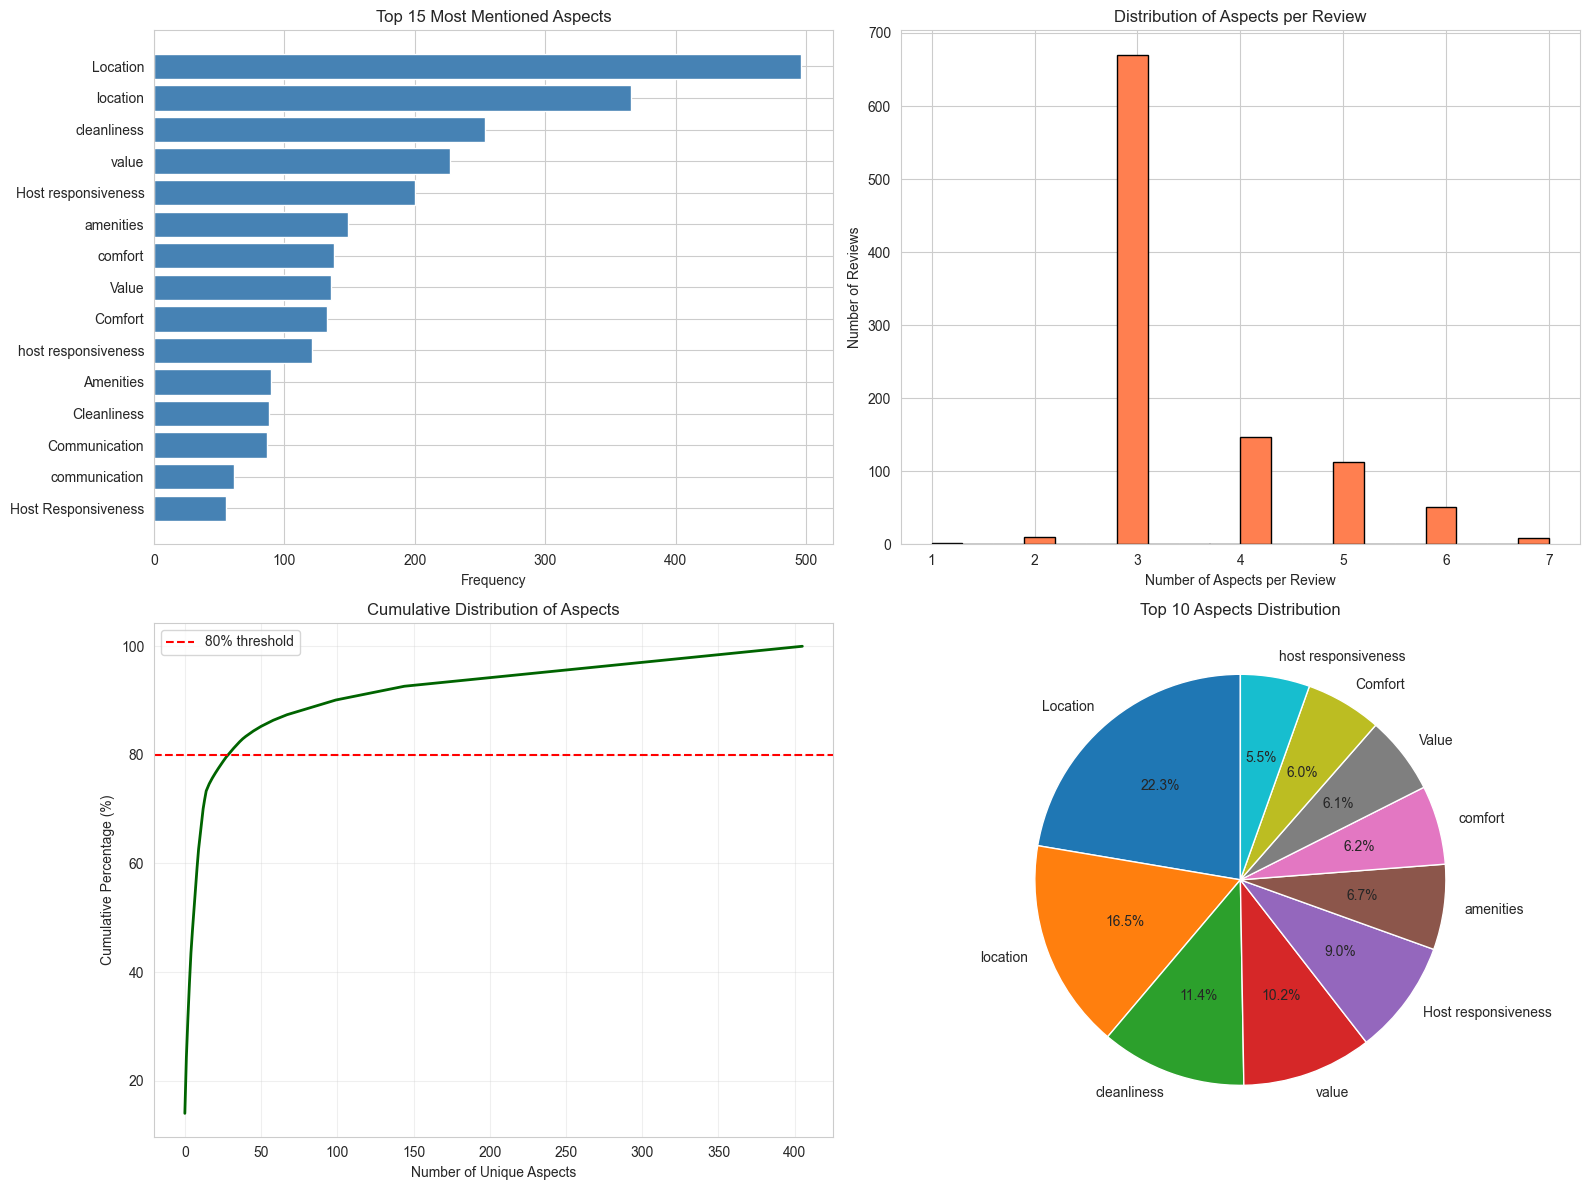

Visualization completed!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 15 Aspects Bar Chart
top_aspects = aspect_counts.most_common(15)
aspects_names, aspects_values = zip(*top_aspects)
axes[0, 0].barh(aspects_names, aspects_values, color='steelblue')
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].set_title('Top 15 Most Mentioned Aspects')
axes[0, 0].invert_yaxis()

# 2. Aspects per Review Distribution
axes[0, 1].hist(reviews_df['aspects_count'], bins=20, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Number of Aspects per Review')
axes[0, 1].set_ylabel('Number of Reviews')
axes[0, 1].set_title('Distribution of Aspects per Review')

# 3. Cumulative Aspects
sorted_aspects = sorted(aspect_counts.values(), reverse=True)
cumulative = np.cumsum(sorted_aspects)
cumulative_pct = (cumulative / cumulative[-1]) * 100
axes[1, 0].plot(cumulative_pct, linewidth=2, color='darkgreen')
axes[1, 0].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[1, 0].set_xlabel('Number of Unique Aspects')
axes[1, 0].set_ylabel('Cumulative Percentage (%)')
axes[1, 0].set_title('Cumulative Distribution of Aspects')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Top 10 Aspects Pie Chart
top_10_aspects = aspect_counts.most_common(10)
aspects_names_10, aspects_values_10 = zip(*top_10_aspects)
axes[1, 1].pie(aspects_values_10, labels=aspects_names_10, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Top 10 Aspects Distribution')

plt.tight_layout()
plt.show()

print("Visualization completed!")

## 8. Save Results to CSV

In [11]:
# Convert aspects list to string for CSV storage
reviews_df['aspects_string'] = reviews_df['aspects'].apply(lambda x: '; '.join(x) if x else '')

# Create output dataframe with relevant columns
output_df = reviews_df[['comments', 'aspects_string', 'aspects_count']].copy()
output_df.columns = ['Review', 'Aspects', 'Aspect_Count']

# Save to CSV
output_filename = 'aspect_extraction_results.csv'
output_df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"Results saved to: {output_filename}")
print(f"Total records saved: {len(output_df)}")

# Also save aspect statistics
stats_df = pd.DataFrame(aspect_counts.most_common(), columns=['Aspect', 'Frequency'])
stats_df['Percentage'] = (stats_df['Frequency'] / len(reviews_df) * 100).round(2)
stats_filename = 'aspect_statistics.csv'
stats_df.to_csv(stats_filename, index=False, encoding='utf-8')

print(f"Statistics saved to: {stats_filename}")
print(f"\nPreview of results:")
print(output_df.head(10))

Results saved to: aspect_extraction_results.csv
Total records saved: 1000
Statistics saved to: aspect_statistics.csv

Preview of results:
                                              Review  \
0  Alloggio confortevole e pratico, dotato di tut...   
1  Très bon emplacement pour cet appartement typi...   
2  What a wonderful gem.  Great location, it was ...   
3  We had a lovely 3 night stay.  Everything was ...   
4  Great location. Very calm and quiet. Small but...   
5  we loved this apartment, very convenient, easy...   
6  Awesome communication via texting to insure an...   
7                               Nice place best spot   
8  Lovely home in a quaint and serene neighborhoo...   
9  Borzou’s apartment is, in my humble opinion, i...   

                                             Aspects  Aspect_Count  
0                       Comfort; location; quietness             3  
1                    Location; Centrality; Quietness             3  
2         Location; cleanliness; renov